<a href="https://colab.research.google.com/github/viniciusarnom/mestrado_inteligencia_artificial/blob/main/Random_Forest_Wi_Fi_BES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Carregar os dados de S1 (Dia 1) - 5000 amostras
data = np.fromfile("WiFi_Day_1_bes_s1.bin", dtype=np.complex64, count=5000)

I = np.real(data)
Q = np.imag(data)

# 2. Calcular o Espectro (Transformada de Fourier) para ser o nosso Alvo (Target - y)
X_f = np.fft.fft(data)
X_f_shifted = np.fft.fftshift(X_f)
y = np.abs(X_f_shifted) # Magnitude do Espectro

# 3. Preparar as Features (X)
# X será uma matriz onde cada linha é um par [I, Q]
X = np.column_stack((I, Q))

# 4. Dividir os dados: 70% Treino e 30% Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Criar e treinar o modelo Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 6. Fazer previsões no conjunto de teste (30%)
y_pred = rf_model.predict(X_test)

# 7. Avaliar as Métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

MSE: 0.0276
R² Score: -0.2808


Treinando o modelo Random Forest...
MSE: 0.0276
R² Score: -0.2808
Gráfico gerado e salvo como rf_spectrum_prediction.png


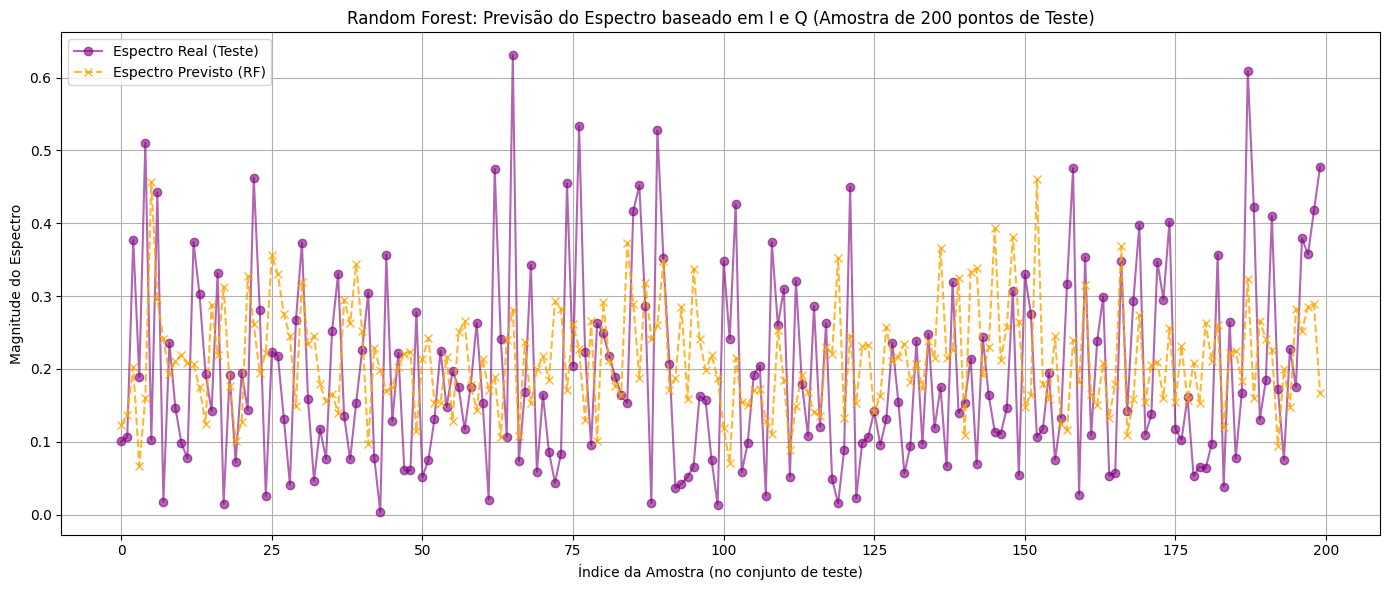

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Carregar os dados (vamos usar o WiFi_Day_1_bes_s1.bin com 5000 amostras para manter o treino rápido)
data = np.fromfile('WiFi_Day_1_bes_s1.bin', dtype=np.complex64, count=5000)

I = np.real(data)
Q = np.imag(data)

# 2. Calcular o Espectro (Target - y)
# Usar a magnitude da Transformada de Fourier centralizada
X_f = np.fft.fft(data)
X_f_shifted = np.fft.fftshift(X_f)
spectrum_magnitude = np.abs(X_f_shifted)

# 3. Preparar as Features (X) e o Target (y)
# X será uma matriz onde cada linha tem [I, Q]
X = np.column_stack((I, Q))
y = spectrum_magnitude

# 4. Dividir os dados em Treino (70%) e Teste (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Criar e treinar o modelo Random Forest
print("Treinando o modelo Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 6. Fazer previsões no conjunto de teste
y_pred = rf_model.predict(X_test)

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# 7. Plotar os resultados (Comparação entre o Real e o Previsto para uma amostra dos testes)
plt.figure(figsize=(14, 6))

# Para melhor visualização, vamos ordenar os valores ou apenas plotar os 200 primeiros pontos do teste
subset_size = 200
plt.plot(y_test[:subset_size], label='Espectro Real (Teste)', color='purple', marker='o', linestyle='-', alpha=0.6)
plt.plot(y_pred[:subset_size], label='Espectro Previsto (RF)', color='orange', marker='x', linestyle='--', alpha=0.8)

plt.title('Random Forest: Previsão do Espectro baseado em I e Q (Amostra de 200 pontos de Teste)')
plt.xlabel('Índice da Amostra (no conjunto de teste)')
plt.ylabel('Magnitude do Espectro')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('rf_spectrum_prediction.png')
print("Gráfico gerado e salvo como rf_spectrum_prediction.png")